In [1]:
import sklearn
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.model_selection import train_test_split
from helper_functions import plot_predictions, plot_decision_boundary

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [7]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("Helper Functions .py file already exists, Skipping Download")
else:
    print("Donwloading Helper Functions .py")
    requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(requests.content)


Helper Functions .py file already exists, Skipping Download


In [19]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct//len(y_pred)) * 100

    return acc    

In [5]:
n_samples = 1000
X,y = make_circles(n_samples, noise = 0.03, random_state = 42)

In [4]:
len(X),len(y)

(1000, 1000)

In [5]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]


In [6]:
X.shape

(1000, 2)

In [7]:
y.shape

(1000,)

In [8]:
circles = pd.DataFrame({"X1":X[:,0], "X2":X[:,1],"label":y})
circles.head(5)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [66]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

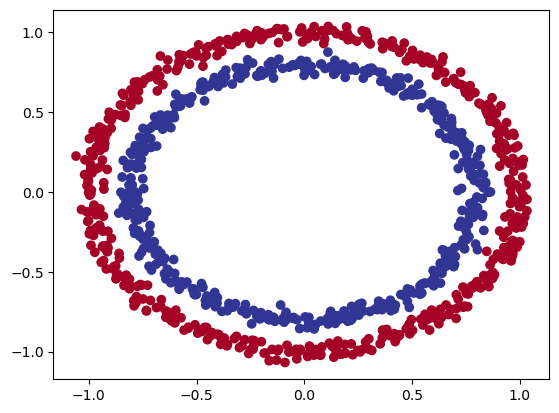

In [9]:
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [10]:
# Convert data to tensors

torch.__version__
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [11]:
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [4]:
# Splitting

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

len(X_train),len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [14]:
X_train.shape

torch.Size([800, 2])

In [15]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2,5)
        self.layer_2 = nn.Linear(5,1)

        self.two_linear_layers = nn.Sequential(
            nn.Linear(2,5),
            nn.Linear(5,1),
        )

    def forward(self,x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        return x
        #return two_linear_layers(x)

In [16]:
model_circle = CircleModelV0().to(device)
model_circle

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [17]:
model_0 = nn.Sequential(
    nn.Linear(2,5),
    nn.Linear(5,1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
model_circle.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.1009,  0.1074],
                      [-0.6317, -0.2047],
                      [ 0.2867,  0.1015],
                      [ 0.0669, -0.5898],
                      [-0.0913, -0.0596]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.2978,  0.0630, -0.2585,  0.3594, -0.1327], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.3179,  0.2113, -0.2092,  0.0987,  0.3862]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.1699], device='cuda:0')),
             ('two_linear_layers.0.weight',
              tensor([[ 0.0375, -0.4867],
                      [-0.1793,  0.2824],
                      [ 0.6490, -0.6479],
                      [ 0.1251,  0.2906],
                      [-0.1004,  0.1568]], device='cuda:0')),
             ('two_linear_layers.0.bias',
              tensor([-0.1981,  0.0725,  0.1372,  0.5047, -0.1369], device='cuda:0')),
             ('two_linear_laye

In [19]:
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function built in
# loss_fn = nn.BCELoss() 
optimizer_fn = torch.optim.SGD(params = model_circle.parameters(),lr = 0.03)

In [21]:
model_circle.eval()
with torch.inference_mode():
    y_logits = model_circle(X_test.to(device))[:5]
y_logits

tensor([[-0.2178],
        [-0.3229],
        [-0.0442],
        [-0.2665],
        [-0.2064]], device='cuda:0')

In [44]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4458],
        [0.4200],
        [0.4889],
        [0.4338],
        [0.4486]], device='cuda:0')

In [48]:
y_preds = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(model_circle(X_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [50]:
!nvidia-smi

Sun Jul 20 12:05:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.42                 Driver Version: 572.42         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   42C    P8              3W /   50W |     623MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [70]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_circle.train()

    # forward pass
    y_logits = model_circle(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer_fn.zero_grad()

    loss.backward()
    optimizer_fn.step()

    model_circle.eval()
    with torch.inference_mode():
        test_logits = model_circle(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")
    

Epoch: 0 | Loss: 0.693016, Acc: 0.00% | Test Loss: 0.69394, Test Acc: 0.00%
Epoch: 10 | Loss: 0.693015, Acc: 0.00% | Test Loss: 0.69395, Test Acc: 0.00%
Epoch: 20 | Loss: 0.693013, Acc: 0.00% | Test Loss: 0.69397, Test Acc: 0.00%
Epoch: 30 | Loss: 0.693012, Acc: 0.00% | Test Loss: 0.69398, Test Acc: 0.00%
Epoch: 40 | Loss: 0.693010, Acc: 0.00% | Test Loss: 0.69400, Test Acc: 0.00%
Epoch: 50 | Loss: 0.693009, Acc: 0.00% | Test Loss: 0.69401, Test Acc: 0.00%
Epoch: 60 | Loss: 0.693008, Acc: 0.00% | Test Loss: 0.69402, Test Acc: 0.00%
Epoch: 70 | Loss: 0.693007, Acc: 0.00% | Test Loss: 0.69403, Test Acc: 0.00%
Epoch: 80 | Loss: 0.693006, Acc: 0.00% | Test Loss: 0.69405, Test Acc: 0.00%
Epoch: 90 | Loss: 0.693005, Acc: 0.00% | Test Loss: 0.69406, Test Acc: 0.00%


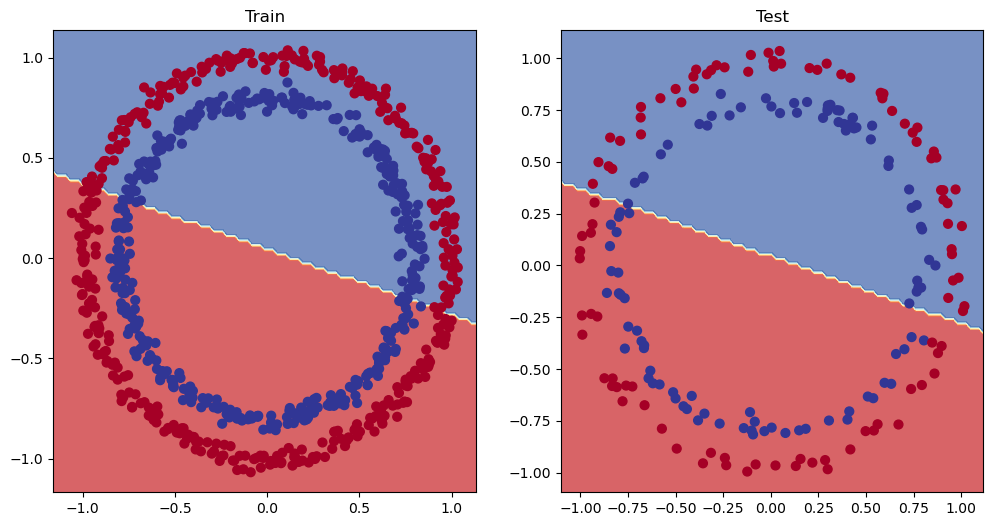

In [80]:
# Plotting decision boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # rows, cols, index
plt.title("Train")
plot_decision_boundary(model_circle, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_circle, X_test, y_test)

In [82]:
''' To improve predictions - 
1. Add more layers to give a chance to learn more patterns
2. add more hidden layers
3. Train for more Epochs
4. Change Activation Functino
5. Change learning Rate
6. Change Loss function
7. Change Optimizer Function'''

' To improve predictions - \n1. Add more layers to give a chance to learn more patterns\n2. add more hidden layers\n3. Train for more Epochs\n4. Change Activation Functino\n5. Change learning Rate\n6. Change Loss function\n7. Change Optimizer Function'

In [17]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2,10)
        self.layer_2 = nn.Linear(10,10)
        self.layer_3 = nn.Linear(10,1)

    def forward(self, x):
        #z = self.layer_1(x)
        #z = self.layer_2(x)
        #z = self.layer_3(x)
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1
        

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [86]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.01)

In [88]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test) 
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 0.69396, Acc: 0.00% | Test Loss: 0.69261, Test Acc: 0.00%
Epoch: 100 | Loss: 0.69369, Acc: 0.00% | Test Loss: 0.69269, Test Acc: 0.00%
Epoch: 200 | Loss: 0.69351, Acc: 0.00% | Test Loss: 0.69282, Test Acc: 0.00%
Epoch: 300 | Loss: 0.69339, Acc: 0.00% | Test Loss: 0.69295, Test Acc: 0.00%
Epoch: 400 | Loss: 0.69329, Acc: 0.00% | Test Loss: 0.69309, Test Acc: 0.00%
Epoch: 500 | Loss: 0.69322, Acc: 0.00% | Test Loss: 0.69322, Test Acc: 0.00%
Epoch: 600 | Loss: 0.69317, Acc: 0.00% | Test Loss: 0.69335, Test Acc: 0.00%
Epoch: 700 | Loss: 0.69313, Acc: 0.00% | Test Loss: 0.69347, Test Acc: 0.00%
Epoch: 800 | Loss: 0.69309, Acc: 0.00% | Test Loss: 0.69358, Test Acc: 0.00%
Epoch: 900 | Loss: 0.69307, Acc: 0.00% | Test Loss: 0.69368, Test Acc: 0.00%


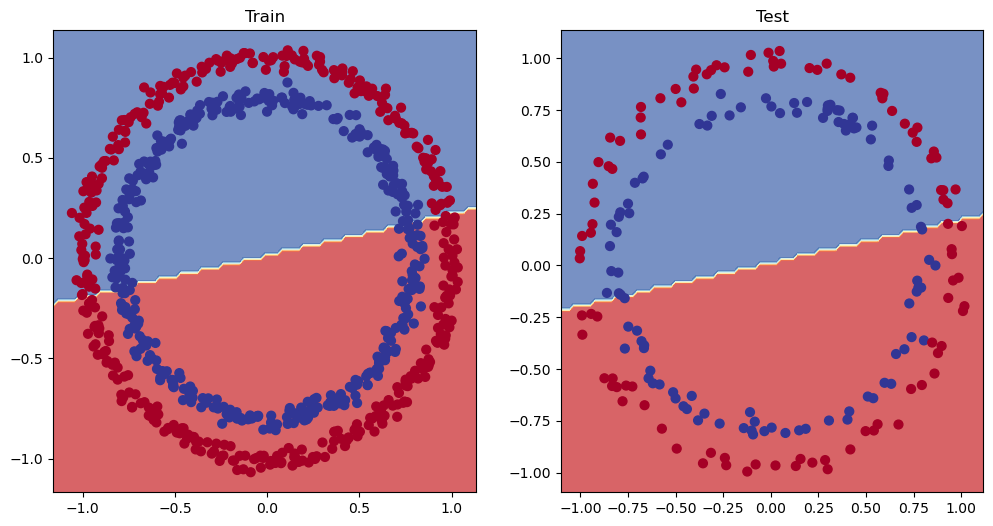

In [92]:
# Plotting decision boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1) # rows, cols, index
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [96]:
# 11:30:00

In [9]:
weight = 0.7
bias = 0.3
start = 0 
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [13]:
X_train_regression,X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression,y_regression,  test_size = 0.2, random_state = 42)
len(X_train_regression),len(X_test_regression),len(y_train_regression),len(y_test_regression)

(80, 20, 80, 20)

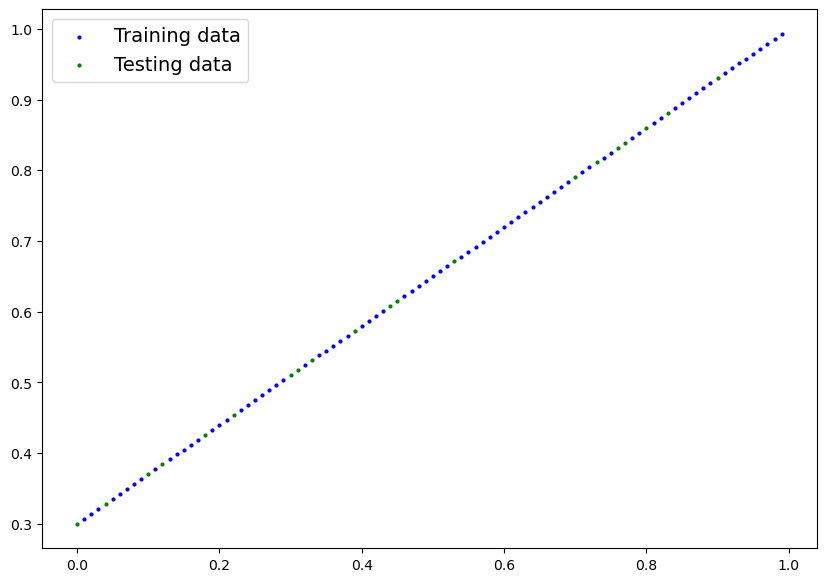

In [9]:
plot_predictions(X_train_regression, y_train_regression, X_test_regression,y_test_regression)

In [19]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [5]:
model_2 = nn.Sequential(
    nn.Linear(1,10),
    nn.Linear(10,20),
    nn.Linear(20,1),
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=20, bias=True)
  (2): Linear(in_features=20, out_features=1, bias=True)
)

In [17]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr = 0.01)

In [19]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_regression, y_train_regression,X_test_regression, y_test_regression = X_train_regression.to(device),y_train_regression.to(device),X_test_regression.to(device),y_test_regression.to(device)

for epoch in range(epochs):
    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.10795 | Test Loss: 0.10814
Epoch: 100 | Loss: 0.02977 | Test Loss: 0.03704
Epoch: 200 | Loss: 0.03820 | Test Loss: 0.02699
Epoch: 300 | Loss: 0.03407 | Test Loss: 0.02963
Epoch: 400 | Loss: 0.03178 | Test Loss: 0.02767
Epoch: 500 | Loss: 0.03298 | Test Loss: 0.02737
Epoch: 600 | Loss: 0.03241 | Test Loss: 0.02640
Epoch: 700 | Loss: 0.03157 | Test Loss: 0.02581
Epoch: 800 | Loss: 0.03165 | Test Loss: 0.02435
Epoch: 900 | Loss: 0.02999 | Test Loss: 0.02474


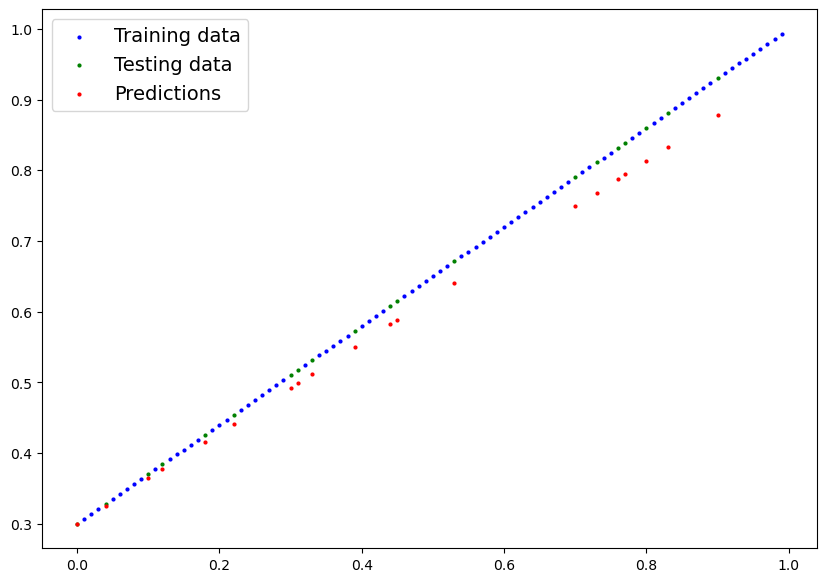

In [25]:
model_2.eval()

with torch.inference_mode():
    y_preds = model_2(X_test_regression)

plot_predictions(X_train_regression.cpu(),y_train_regression.cpu(), X_test_regression.cpu(), y_test_regression.cpu(), y_preds.cpu())

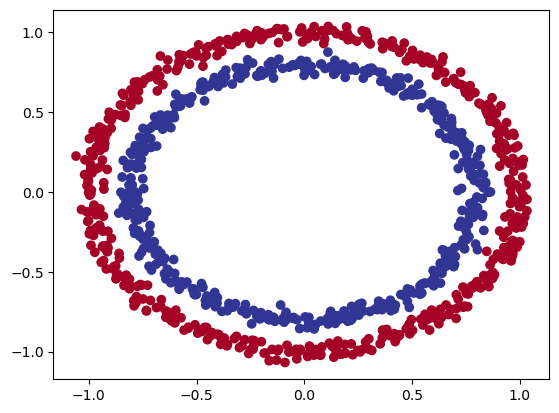

In [49]:
n_samples = 1000
X,y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [51]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [57]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2,10)
        self.layer_2 = nn.Linear(10,10)
        self.layer_3 = nn.Linear(10,1)
        self.relu = nn.ReLU() 
        self.sigmoid = nn.Sigmoid()

    def forward(self,X):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [71]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),lr=0.01) 

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

epochs = 10000

for epoch in range(epochs):
    model_3.train()

    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_3.eval()

    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

In [79]:
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

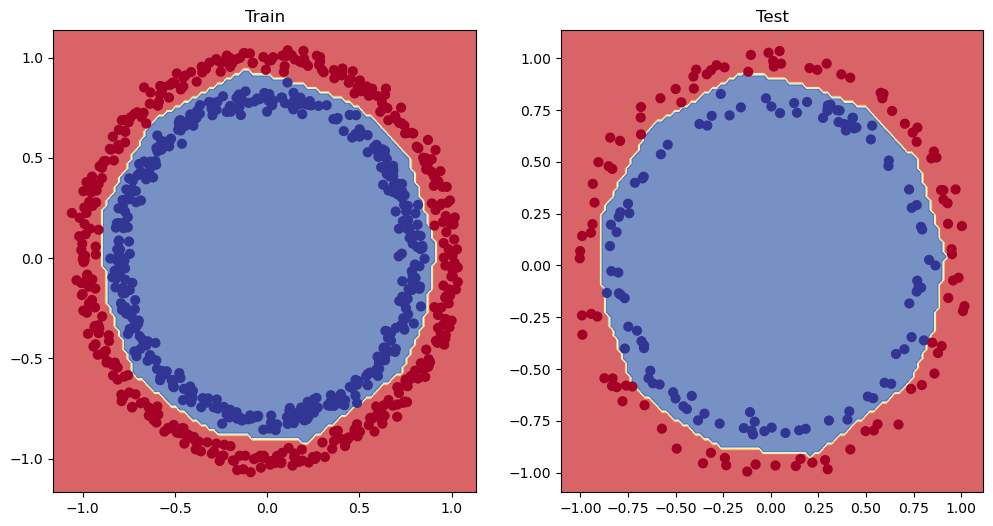

In [81]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")

plot_decision_boundary(model_3, X_train, y_train)

plt.subplot(1,2,2)
plt.title("Test")

plot_decision_boundary(model_3, X_test,y_test)

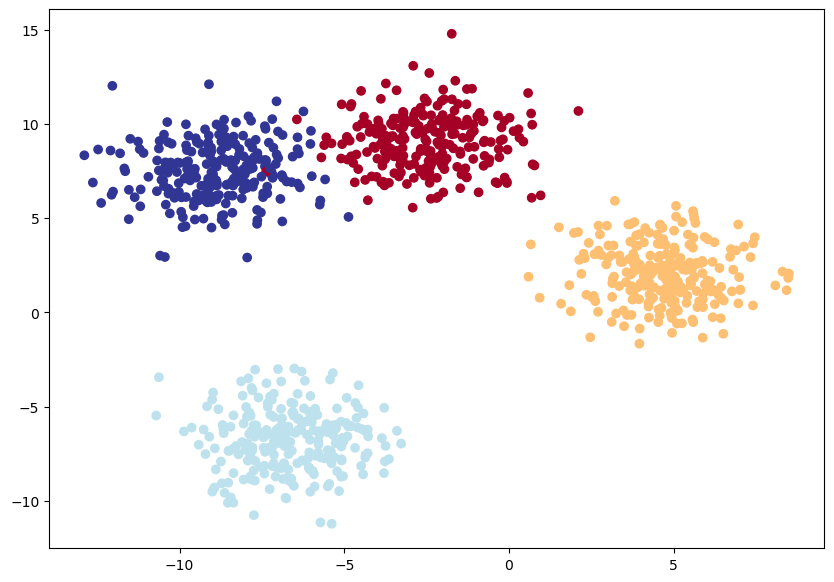

In [131]:
num_classes = 4
num_features = 2
random_seed = 42

X_blob, y_blob = make_blobs(n_samples=1000, n_features=num_features, centers=num_classes, cluster_std=1.5, random_state=random_seed)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2, random_state=random_seed)

plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap = plt.cm.RdYlBu)

In [132]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features,hidden_units=32):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features = hidden_units),
            #nn.Dropout(p=0.2),
            #nn.ReLU(),
            nn.Linear(hidden_units, hidden_units),
            #nn.Dropout(p=0.2),
            #nn.ReLU(),
            nn.Linear(hidden_units, output_features)
        )
        
    def forward(self, X):
        return self.linear_layer_stack(X)

model_4 = BlobModel(input_features = 2, output_features=4, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [135]:
X_blob_train.shape

torch.Size([800, 2])

In [137]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [139]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = X_blob_train.to(device), X_blob_test.to(device), y_blob_train.to(device), y_blob_test.to(device)

epochs = 100

for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_blob_train, y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_blob_test, test_preds)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}%")

Epoch: 0 | Loss: 1.0432, Acc: 0.00% | Test Loss: 0.5786, Test Acc: 0.0000%
Epoch: 10 | Loss: 0.1440, Acc: 0.00% | Test Loss: 0.1304, Test Acc: 0.0000%
Epoch: 20 | Loss: 0.0806, Acc: 0.00% | Test Loss: 0.0722, Test Acc: 0.0000%
Epoch: 30 | Loss: 0.0592, Acc: 0.00% | Test Loss: 0.0513, Test Acc: 0.0000%
Epoch: 40 | Loss: 0.0489, Acc: 0.00% | Test Loss: 0.0410, Test Acc: 0.0000%
Epoch: 50 | Loss: 0.0429, Acc: 0.00% | Test Loss: 0.0349, Test Acc: 0.0000%
Epoch: 60 | Loss: 0.0391, Acc: 0.00% | Test Loss: 0.0308, Test Acc: 0.0000%
Epoch: 70 | Loss: 0.0364, Acc: 0.00% | Test Loss: 0.0280, Test Acc: 0.0000%
Epoch: 80 | Loss: 0.0345, Acc: 0.00% | Test Loss: 0.0259, Test Acc: 0.0000%
Epoch: 90 | Loss: 0.0330, Acc: 0.00% | Test Loss: 0.0242, Test Acc: 0.0000%


In [141]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[  4.3377,  10.3539, -14.8948,  -9.7642],
        [  5.0142, -12.0371,   3.3860,  10.6699],
        [ -5.5885, -13.3448,  20.9894,  12.7711],
        [  1.8400,   7.5599,  -8.6016,  -6.9942],
        [  8.0726,   3.2906, -14.5998,  -3.6186],
        [  5.5844, -14.9521,   5.0168,  13.2890],
        [ -5.9739, -10.1913,  18.8655,   9.9179],
        [  7.0755,  -0.7601,  -9.5531,   0.1736],
        [ -5.5918, -18.5990,  25.5309,  17.5799],
        [  7.3142,   0.7197, -11.2017,  -1.2011]], device='cuda:0')

In [143]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[2.4332e-03, 9.9757e-01, 1.0804e-11, 1.8271e-09],
        [3.4828e-03, 1.3698e-10, 6.8363e-04, 9.9583e-01],
        [2.8657e-12, 1.2267e-15, 9.9973e-01, 2.6959e-04],
        [3.2692e-03, 9.9673e-01, 9.5436e-08, 4.7619e-07],
        [9.9168e-01, 8.3089e-03, 1.4120e-10, 8.2969e-06],
        [4.5039e-04, 5.4288e-13, 2.5532e-04, 9.9929e-01],
        [1.6306e-11, 2.4030e-13, 9.9987e-01, 1.3003e-04],
        [9.9860e-01, 3.9485e-04, 5.9938e-08, 1.0045e-03],
        [3.0436e-14, 6.8305e-20, 9.9965e-01, 3.5218e-04],
        [9.9843e-01, 1.3657e-03, 9.0768e-09, 2.0006e-04]], device='cuda:0')

In [145]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

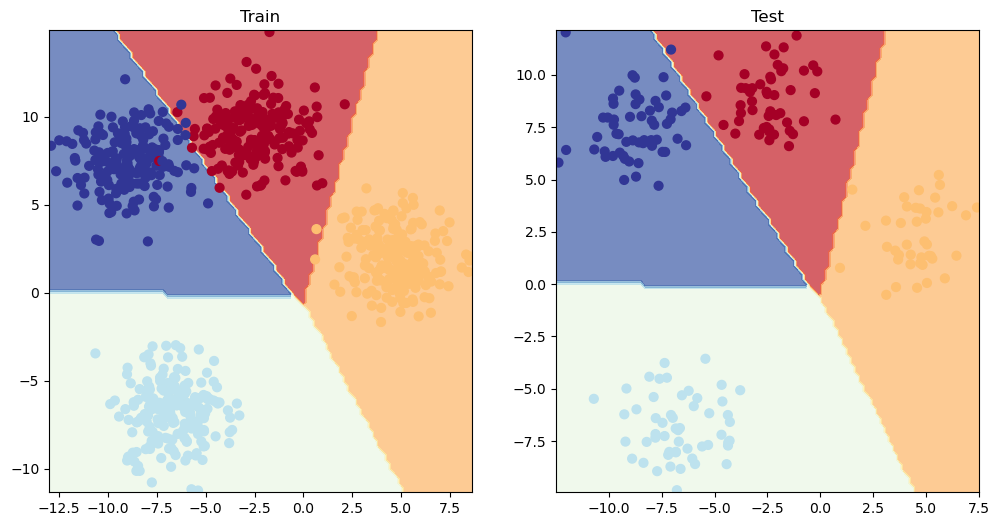

In [147]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test,y_blob_test)